# Calibration & accuracy vs admixture age

tslai's edge is a **calibrated** soft posterior. Here we show the reliability of `P(A)` and how
discrimination decays as admixture ages (the reference signal is lost when admixed lineages
coalesce among themselves before an old pulse — a coalescent limit, not tree-inference error).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import tslai
from tslai.sim import SOURCE_A, SOURCE_B, ADMIXED

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False})

def admixture(n_admix=8, n_ref=8, L=2e6, T_admix=100, Ne=1000, T_split=5000, f_A=0.5,
              seed=1, infer=False, mutation_rate=4e-7):
    """Simulate admixture with known truth; return (ts, labels, queries, truth_states)."""
    ts = tslai.simulate_admixture(n_admix=n_admix, n_ref=n_ref, sequence_length=L,
                                  recombination_rate=1e-8, random_seed=seed, Ne=Ne,
                                  T_admix=T_admix, T_split=T_split, f_A=f_A)
    pop = ts.tables.nodes.population
    name = {p: ts.population(p).metadata.get("name", str(p)) for p in range(ts.num_populations)}
    A = next(p for p, n in name.items() if n == SOURCE_A)
    B = next(p for p, n in name.items() if n == SOURCE_B)
    admix = next(p for p, n in name.items() if n == ADMIXED)
    sop = {A: 0, B: 1}
    labels = {int(s): sop[pop[s]] for s in ts.samples() if pop[s] in (A, B)}
    queries = [int(s) for s in ts.samples() if pop[s] == admix]
    truth = tslai.metrics.map_truth({q: tslai.local_ancestry_truth(ts)[0][q] for q in queries}, sop)
    work = ts
    if infer:
        work = tslai.io.infer_tree_sequence(tslai.io.add_mutations(ts, rate=mutation_rate,
                                                                   random_seed=seed))
    return work, labels, queries, truth

CMAP = "RdBu_r"   # red = ancestry A (state 0), blue = ancestry B (state 1)

def plot_painting(painting, truth, ts, title="", segments=None):
    """Soft posterior P(A) painted along the genome per query haplotype, with a thin truth
    strip beneath each. If `segments` (hard tracts) is given, draw those instead of soft."""
    qs = painting.queries
    L = ts.sequence_length
    sm = cm.ScalarMappable(norm=colors.Normalize(0, 1), cmap=CMAP)
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(qs) + 1.2))
    for i, q in enumerate(qs):
        if segments is None:
            for seg in painting.posteriors[q]:
                ax.barh(i, seg.right - seg.left, left=seg.left, height=0.74,
                        color=sm.to_rgba(seg.posterior[0]), edgecolor="none")
        else:
            for (l, r, s) in segments[q]:
                ax.barh(i, r - l, left=l, height=0.74,
                        color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
        for (l, r, s) in truth[q]:
            ax.barh(i - 0.46, r - l, left=l, height=0.13,
                    color=sm.to_rgba(1.0 if s == 0 else 0.0), edgecolor="none")
    ax.set_xlim(0, L); ax.set_ylim(-0.8, len(qs) - 0.2)
    ax.set_yticks(range(len(qs))); ax.set_yticklabels([f"hap {q}" for q in qs], fontsize=8)
    ax.set_xlabel("genomic position (bp)"); ax.set_title(title)
    cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label("P(ancestry A)")
    ax.text(0, len(qs) - 0.5, "thin strip below each = true ancestry", fontsize=7, color="0.4")
    fig.tight_layout()
    return fig

## Reliability diagram

Predicted vs empirical `P(A)`, span-weighted by probability bin (pooled over several seeds for a smooth curve). A calibrated painter lies on the diagonal.

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_78981/1452454447.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


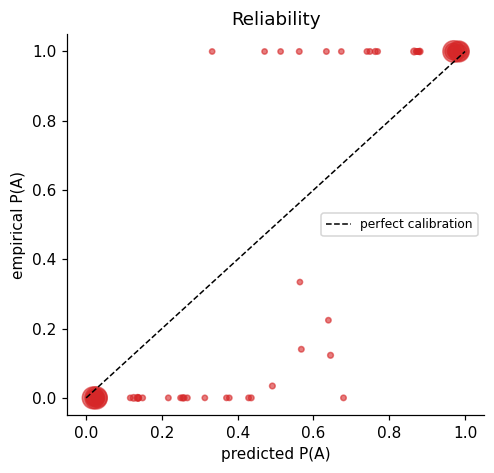

In [2]:
#| label: fig-reliability
#| fig-cap: "Reliability diagram: predicted vs empirical P(ancestry A); marker size ∝ span weight. Points near the diagonal indicate calibration."
import numpy as np
pred, emp, wt = [], [], []
for seed in range(1, 7):
    ts, labels, queries, truth = admixture(n_admix=8, n_ref=8, L=1e6, T_admix=200, seed=seed)
    p = tslai.paint(ts, labels)
    rc = tslai.metrics.reliability_curve(p.posteriors, truth, state=0, n_bins=10)
    pred.append(rc["pred"]); emp.append(rc["emp"]); wt.append(rc["weight"])
# weighted average across seeds, per bin
pred = np.concatenate(pred); emp = np.concatenate(emp); wt = np.concatenate(wt)
order = np.argsort(pred)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.scatter(pred[order], emp[order], s=12 + 200 * wt[order] / wt.max(), alpha=0.6, color="C3")
ax.set_xlabel("predicted P(A)"); ax.set_ylabel("empirical P(A)")
ax.set_title("Reliability"); ax.legend(fontsize=8); fig.tight_layout()
fig.show()

## Accuracy vs admixture age

Balanced accuracy and mean confidence as the admixture pulse ages (deep split, so only the query↔reference link — not tract length — varies).

/var/folders/s6/srs8qkh52w1_h32d65z95tth0000gn/T/ipykernel_78981/1226867233.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


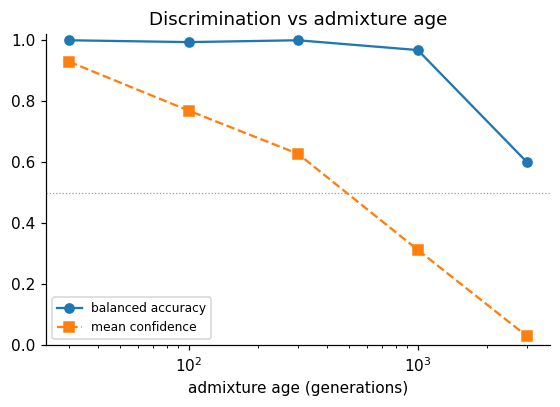

In [3]:
#| label: fig-accuracy-age
#| fig-cap: "Balanced accuracy and confidence vs admixture age: tslai discriminates well at recent–moderate admixture; the reference signal is lost at old admixture under present-day sampling."
ages = [30, 100, 300, 1000, 3000]
rows = tslai.experiments.age_sweep(ages, n_admix=8, n_ref=8, sequence_length=1e6,
                                   Ne=1000, T_split=8000, f_A=0.5, seed=1, max_iter=8)
ba = [r["balanced_accuracy"] for r in rows]; cf = [r["confidence"] for r in rows]
fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.plot(ages, ba, "o-", label="balanced accuracy")
ax.plot(ages, cf, "s--", label="mean confidence", color="C1")
ax.axhline(0.5, color="0.6", lw=0.8, ls=":")
ax.set_xscale("log"); ax.set_xlabel("admixture age (generations)"); ax.set_ylim(0, 1.02)
ax.set_title("Discrimination vs admixture age"); ax.legend(fontsize=8); fig.tight_layout()
fig.show()